In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

#For training improvements
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization


In [2]:
# Path to dataset directory (should contain subfolders like 'with_mask', 'without_mask')
train_dir='data/'

In [3]:
# ImageDataGenerator helps in Utility to load, preprocess, Normalizing images, Augmenting data (rotation, zoom, flip)
train_gen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Go to my dataset folder, load images in batches, apply preprocessing & augmentation, and assign labels automatically
train_data=train_gen.flow_from_directory(
    train_dir,
    # Model cannot handle different sizes so we can Resize all images to 128x128 fixed size which can give more detail and speed
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training',
)

# Load validation data
val_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [4]:
print("Class Labels:",train_data.class_indices)

Class Labels: {'with_mask': 0, 'without_mask': 1}


In [5]:
# 1. Feature Extraction → (Conv + BN + Pool)
# 2. Feature Conversion → (Flatten)
# 3. Decision Making → (Dense + Dropout + Output)

model=Sequential([
    # First Convolution Block
    # (3,3) → Filter Size (Kernel Size) ,Each filter is 3×3, It looks at a small patch of the image at a time, captures local features like edges, corners, textures.
    # input_shape = (128,128,3) -> 128x128 pixels, 3 channels (RGB)
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),  # Extract low-level features
    BatchNormalization(),  # Normalize outputs → stabilizes training

    # Reduce spatial size (downsampling)
    # reduce size + keep important features
    MaxPooling2D(2,2),

    # Second Convolution Block
    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Third Convolution Block
    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    # CNN = Detect edges, shapes
    # Flatten = Convert findings into list
    # Dense = Decide final answer
    # Flatten feature maps into 1D vector

    Flatten(),

    # Fully connected layer
    Dense(128,activation='relu'),         
    # Learn patterns from extracted features
    # Not using dropout after every layer because in CNN it can disturb to feature learning means it can remove information i.e spatial features
    # Here we used Batch normalization to stabilize training, can prevent from overfitting, adds slight regularization.
    # after dense used dropout because dense layer do decision making so not sensitive to spacial structure
    # Prevent overfitting by randomly dropping neurons

    Dropout(0.5),

    # Output layer (binary classification)

    Dense(1,activation='sigmoid')
])


    

    

In [6]:
# Compile model (configure training)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [7]:
# EarlyStopping stops training if validation loss doesn't improve
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ModelCheckpoint saves the best model during training
checkpoint=ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [8]:
# Train the model
history=model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,

    steps_per_epoch=len(train_data),
    validation_steps=len(val_data),
    callbacks=[early_stop,checkpoint]
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.8241 - loss: 0.9531 - val_accuracy: 0.7397 - val_loss: 0.9914
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.8795 - loss: 0.3285 - val_accuracy: 0.7801 - val_loss: 0.5191
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9030 - loss: 0.2502 - val_accuracy: 0.9344 - val_loss: 0.1995
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.9163 - loss: 0.2237 - val_accuracy: 0.9245 - val_loss: 0.1925
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9252 - loss: 0.1941 - val_accuracy: 0.8437 - val_loss: 0.6766
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9239 - loss: 0.1883 - val_accuracy: 0.9543 - val_loss: 0.1534
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9370 - loss: 0.1645 - val_accuracy: 0.5331 - val_loss: 0.9791
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 132s 699ms/step - accuracy: 0.9381 - loss: 0.1643 - val_a

In [11]:
# pip install scipy

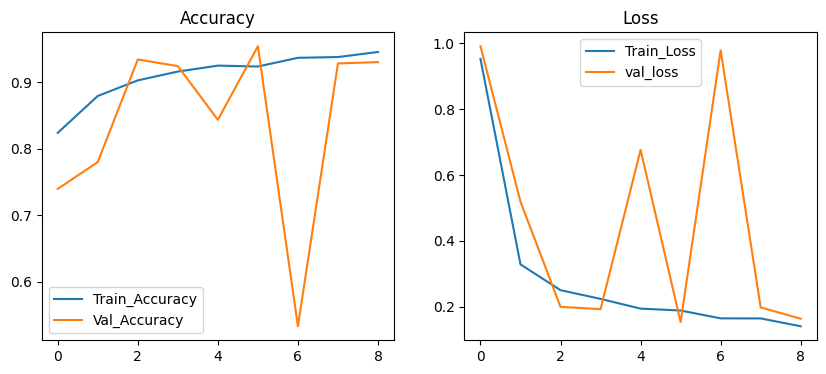

In [12]:
# Plot training results (accuracy & loss)

plt.figure(figsize=(10,4))

# plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train_Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train_Loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title("Loss")
plt.legend()

plt.show()

In [16]:
img_path='image2.jpg'

# Load and resize image
img=image.load_img(img_path,target_size=(128,128))

# Convert image to array and normalize
img_array=image.img_to_array(img)/255.0

# Add batch dimension (model expects shape: (1, 128, 128, 3))
# (1, 128, 128, 3)
#  ↑   ↑    ↑    ↑
#  |   |    |    |
#  |   |    |    └── Channels (RGB)
#  |   |    └────── Width
#  |   └────────── Height
#  └────────────── Batch size
img_array=np.expand_dims(img_array,axis=0)

# Predict probability
prediction=model.predict(img_array)

print("Raw Prediction:",prediction)

# Convert probability to class label
if prediction[0][0] > 0.5:
    print("Prediction: Without Mask ❌😷")
else:
    print("Prediction: WITH Mask ✅😷")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Raw Prediction: [[1.8751057e-07]]
Prediction: WITH Mask ✅😷


In [17]:
# Save trained model to file
model.save("mask_final.keras")
print("Model Saved Succcessfully")

Model Saved Succcessfully
